## Validation of model TKA_SHA_JGA_Mo_240503_3 with Gao data

Using evaluation function from script SHA-S-250820

In [35]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import pandas as pd
from ICIW_Plots import cyclers as ICIW_cyclers
plt.style.use(['ICIWstyle'])
import matplotlib

In [36]:
## import the model
from SHA_S_250820 import methanation_equilibrium

In [37]:
p = np.array([20])*1e5 # p in Pa
T = np.linspace(200 + 273.15, 300 + 273.15, 3) # T in K
gas_type = 'real gas' # choose type of gas from 'ideal gas' and 'real gas'

# Parameter
n0 = np.full((7,),1e-20)
n0[0] = 0.5       # initial mole fraction of CO2
n0[1] = 0.5-5e-20 # initial mole fraction of H2
n0[2] = 1e-20     # initial mole fraction of CH4
n0[3] = 1e-20     # initial mole fraction of H2O
n0[4] = 1e-20     # initial mole fraction of CO
n0[5] = 1e-20     # initial mole fraction of C
n0[6] = 1e-20     # initial mole fraction of Inert

In [38]:
## EQ calculation
results = methanation_equilibrium(T_arr=T,p_arr=p,n0=n0,gas_type=gas_type)

Evaluating methanation equilibrium...

Converged calculations: 100% (3/3)



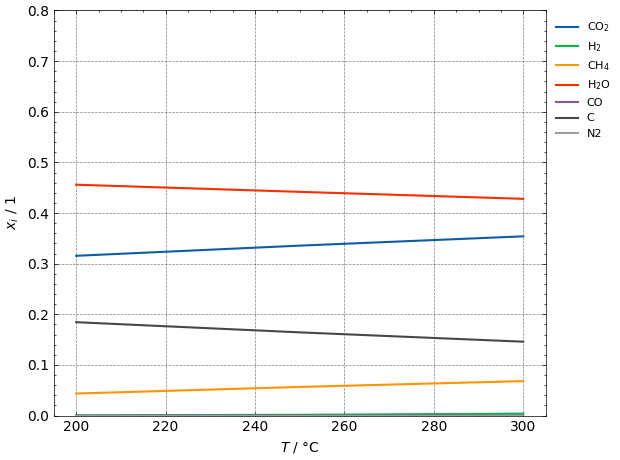

In [39]:
# plt.style.use('ICIWstyle')
font = {'size': 10}
matplotlib.rc('font', **font)

## CO2 methanation
fig, axs = plt.subplots()


axs.plot(T - 273.15,  results['x_eq_CO2'].values,     '-',                 label = 'CO$_2$')
axs.plot(T - 273.15,  results['x_eq_H2'].values,     '-',                 label = 'H$_2$')
axs.plot(T - 273.15,  results['x_eq_CH4'].values,     '-',                 label = 'CH$_4$')
axs.plot(T - 273.15,  results['x_eq_H2O'].values,     '-',                 label = 'H$_2$O')
axs.plot(T - 273.15,  results['x_eq_CO'].values,     '-',                 label = 'CO')
axs.plot(T - 273.15,  results['x_eq_C'].values,     '-',                 label = 'C')
axs.plot(T - 273.15,  results['x_eq_N2'].values,     '-',                 label = 'N2')
axs.set_xlabel('$T$ / °C')
axs.set_ylabel('$x_i$ / 1')
axs.set_ylim(0, 0.8)
plt.legend(bbox_to_anchor=(1,1), loc="upper left", fontsize = 8)
plt.tight_layout()
plt.show()

In [40]:
x_eq_H2 = results[results['temperature']==300+273.15]['x_eq_H2'].values
x_eq_CO = results[results['temperature']==300+273.15]['x_eq_CO'].values

print(x_eq_H2)
print(x_eq_CO)

H2_CO = x_eq_H2/x_eq_CO 
print(H2_CO)

[0.00384852]
[7.8878907e-05]
[48.79019508]
